In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [2]:
from typing import Annotated, TypedDict
import uuid
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langgraph.graph import START, MessagesState, StateGraph, add_messages,END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig

memory=MemorySaver()
in_memory_store=InMemoryStore()

class AgentState(TypedDict):
    user_input:str
    model_response:str
    user_approval:str
    
def call_model(state):
    print("call_model start")
    messages=state['user_input']
    if '删除' in messages:
        state['user_approval']=f"用户输入的指令是:{messages}, 请人工确认是否执行"
    else:
        result=llm.invoke(messages)
        state['model_response']=result
        state['user_approval']="直接执行"
    print("call_model end")    
    return state

def execute_function(state):
    print('execute_function start')
    approval=state['user_approval']
    if approval == '是':
        response="你的删除请求已批准"
        return {'model_response':AIMessage(content=response)}
    elif approval == '否':
        response="你的删除请求已拒绝"
        return {'model_response':AIMessage(content=response)}
    else:
        return state
    
def translate_to(state):
    print('transalate to start')
    messages=state['model_response']
    system_prompt="将消息翻译成英文"
    result=llm.invoke([SystemMessage(content=system_prompt)]+[HumanMessage(
        content=messages.content
    )])
    return {'model_response':result}

builder=StateGraph(AgentState)
builder.add_node('call_model',call_model)
builder.add_node('execute_function',execute_function)
builder.add_node('translate_to',translate_to)

builder.add_edge(START,'call_model')
builder.add_edge('call_model','execute_function')
builder.add_edge('execute_function','translate_to')
builder.add_edge('translate_to',END)

graph=builder.compile(checkpointer=memory, interrupt_before=['execute_function'])

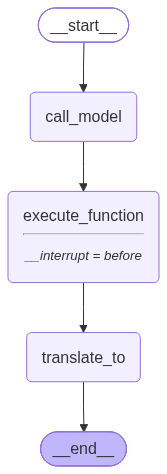

In [3]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
config={'configurable':{'thread_id':"3"}}

async for event in graph.astream_events({'user_input':"我将在数据库中删除id为xigualaosi的所有信息"},config,stream_mode="values"):
    if event['event']=='on_chat_model_stream':
        print(event['data']['chunk'].content,end='|',flush=True)

call_model start
call_model end


In [5]:
snapshot=graph.get_state(config)
snapshot

StateSnapshot(values={'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '用户输入的指令是:我将在数据库中删除id为xigualaosi的所有信息, 请人工确认是否执行'}, next=('execute_function',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1e67-f8b2-6a66-8001-76107ff1f9a6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-27T07:11:17.957283+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1e67-f871-6f22-8000-e6df616c08ec'}}, tasks=(PregelTask(id='fa1333c7-06e4-d667-27d1-bf72f2a4bb6b', name='execute_function', path=('__pregel_pull', 'execute_function'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [6]:
snapshot.values['user_approval']='是'
graph.update_state(config,snapshot.values)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a1e67-f8ed-68ff-8002-b767e50916cc'}}

In [7]:
snapshot=graph.get_state(config)
snapshot

StateSnapshot(values={'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '是'}, next=('execute_function',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1e67-f8ed-68ff-8002-b767e50916cc'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-08-27T07:11:17.981414+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1e67-f8b2-6a66-8001-76107ff1f9a6'}}, tasks=(PregelTask(id='384e3a42-9524-2aa5-a1c2-1e600c2aaa25', name='execute_function', path=('__pregel_pull', 'execute_function'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [8]:
config={'configurable':{'thread_id':"3"}}

async for chunk in graph.astream(None,config,stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'user_approval': '是'}
execute_function start
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='你的删除请求已批准', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), 'user_approval': '是'}
transalate to start
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 14}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '0a5295a3-9919-46e2-90a5-7e87f995d22b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0420f-0eae-7f21-85ba-75d78ece344e

In [9]:
config={'configurable':{'thread_id':"3"}}

async for event in graph.astream_events({'user_input':"我将在数据库中删除id为xigualaosi的所有信息"},config,stream_mode="values"):
    if event['event']=='on_chat_model_stream':
        print(event['data']['chunk'].content,end='|',flush=True)

call_model start
call_model end


In [10]:
snapshot=graph.get_state(config)
snapshot


StateSnapshot(values={'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 14}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '0a5295a3-9919-46e2-90a5-7e87f995d22b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0420f-0eae-7f21-85ba-75d78ece344e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'user_approval': '用户输入的指令是:我将在数据库中删除id为xigualaosi的所有信息, 请人工确认是否执行'}, next=('execute_function',), co

In [11]:
snapshot.values['user_approval']='否'
graph.update_state(config,snapshot.values)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a1e68-6b1f-6707-8008-46e2da3a6cef'}}

In [12]:
config={'configurable':{'thread_id':"3"}}

async for chunk in graph.astream(None,config,stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 14}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '0a5295a3-9919-46e2-90a5-7e87f995d22b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0420f-0eae-7f21-85ba-75d78ece344e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'user_approval': '否'}
execute_function start
{'user_input': '我将在数据库中删除id为xigualaosi的所有信息', 'model_response': AIMessage(c

In [13]:
config={'configurable':{'thread_id':"3"}}

async for event in graph.astream_events({'user_input':["你好，介绍一下你自己"]},config,stream_mode="values"):
    if event['event']=='on_chat_model_stream':
        print(event['data']['chunk'].content,end='|',flush=True)
        
async for chunk in graph.astream(None, config, stream_mode="values"):
    print(chunk)

call_model start
|你好|呀|！|很高兴|认识|你|！|😊|

|我是|**|Deep|Se|ek|**|，|由|深度|求|索|公司|创造的|AI|助手|。|让我|给你|介绍一下|我的|“|特长|”|：

|✨| **|我的|能力|**|：
|-| **|知识|广|博|**|：|我的|知识|截止|到|202|5|年|5|月|，|涵盖|各个|领域|
|-| **|超|长|上下文|**|：|支持|1|M|上下文|，|可以|一次性|处理|像|《|三|体|》|三部|曲|那么|大体|量的|内容|
|-| **|多|文件|处理|**|：|支持|上传|图像|、|txt|、|pdf|、|ppt|、|word|、|ex|cel|等|文件|，|从中|读取|文字|信息|帮你|处理|
|-| **|联网|搜索|**|：|支持|联网|查询|最新|信息|（|需要|你在|Web|/|App|端|手动|开启|）
|-| **|语音|输入|**|：|App|端|支持|语音|交互|，|更方便|快捷|

|🎁| **|最重要的是|**|：|我|**|完全|免费|**|！|没有任何|收费|计划|，|你可以|放心|使用|。

|📱| |你可以|通过|官方|应用|商店|下载|App|，|随时随地|和我|聊天|。

|💡| **|我的|风格|**|：|我喜欢|用|热情|、|细腻|的方式|和你|交流|，|力求|让|每次|对话|都|温暖|而有|帮助|。|我会|用|你|使用的|语言|回复|你|，|让|沟通|更|自然|。

|有什么|我可以|帮|你的|吗|？|无论是|学习|、|工作|、|生活|还是|闲聊|，|我|都很|乐意|陪你|聊聊|！|🌟|||call_model end
{'user_input': ['你好，介绍一下你自己'], 'model_response': AIMessage(content='你好呀！很高兴认识你！😊\n\n我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：\n\n✨ **我的能力**：\n- **知识广博**：我的知识截止到2025年5月，涵盖各个领域\n- **超长上下文**：支持1M上下文，可以一次性处理像《三体》三部曲那么大体量的内容\n- **多文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文

In [ ]:
snapshot=graph.get_state(config)
snapshot